# Diabetes prediction: gradient boosting

## Notebook set-up

In [1]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import linspace, interp
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.ensemble import GradientBoostingClassifier

import configuration as config
import functions as funcs

## 1. Data preparation

### 1.1. Load data from disk

In [2]:
# with open(config.DATA_FILE, 'rb') as input_file:
#     dataset=pickle.load(input_file)

# training_df=dataset['training']
# testing_df=dataset['testing']

dataset = funcs.load_data('https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv')

### 1.2. Inspect

In [3]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Baseline model

In [4]:
# Your code here
X = dataset.drop('Outcome', axis=1)
y = dataset['Outcome']

X_train, X_test, y_train, y_test = funcs.train_test_split_data(X, y)

In [5]:
# Your code here... Use a gradient boosting classifier with default options
bsl_model = GradientBoostingClassifier(random_state=42)
bsl_model.fit(X_train, y_train)

y_pred_bsl = bsl_model.predict(X_test)
bsl_acc = accuracy_score(y_test, y_pred_bsl)

print(f"Baseline Gradient Boosting Accuracy: {bsl_acc:.4f}")

Baseline Gradient Boosting Accuracy: 0.7532


In [6]:
cross_val_scores={
    'Model': [],
    'Score': []
}

scores=cross_val_score(
    bsl_model,
    X_train,
    y_train,
    cv=7,
    n_jobs=-1
)

cross_val_scores['Model'].extend(['Baseline']*len(scores))
cross_val_scores['Score'].extend(scores)

print(f'Cross-validation accuracy: {np.mean(scores)*100:.1f} +/- {np.std(scores)*100:.1f}%')

Cross-validation accuracy: 76.6 +/- 4.1%


## 3. Hyperparameter optimization

### 3.1. Hyperparameter grid search

In [7]:
# Your code here...
gradBoost_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5]
}

gradBoost = GradientBoostingClassifier(random_state=42)

gridSrchBoost = GridSearchCV(
    estimator=gradBoost,
    param_grid=gradBoost_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

gridSrchBoost.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'min_samples_leaf': [1, 5],
                         'min_samples_split': [2, 10],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='accuracy')

### 3.2. Hyperparameter optimization results

In [8]:
# Best hyperparameters and cross-validation score
print("Best Hyperparameters for Gradient Boosting:", gridSrchBoost.best_params_)
print("Best Cross-Validation Accuracy: {:.4f}".format(gridSrchBoost.best_score_))

Best Hyperparameters for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.7688


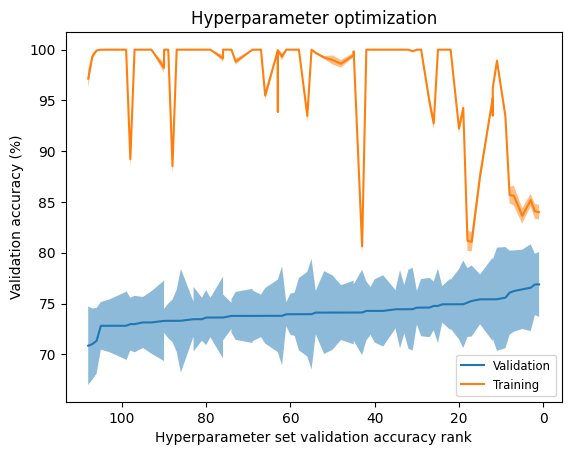

In [9]:
funcs.plot_cross_validation(gridSrchBoost)

### 3.3. Cross-validation of optimized model

In [10]:
# Your code here...
best_gradBoost = gridSrchBoost.best_estimator_

crossVal_score = cross_val_score(best_gradBoost, X_train, y_train, cv=5, scoring='accuracy')


print("Cross-Validation Accuracy Scores:", crossVal_score)
print("Mean CV Accuracy: {:.4f} +/- {:.4f}".format(crossVal_score.mean(), crossVal_score.std()))

Cross-Validation Accuracy Scores: [0.76422764 0.79674797 0.74796748 0.72357724 0.81147541]
Mean CV Accuracy: 0.7688 +/- 0.0319


## 4. Evaluation

### 4.1. Model comparison

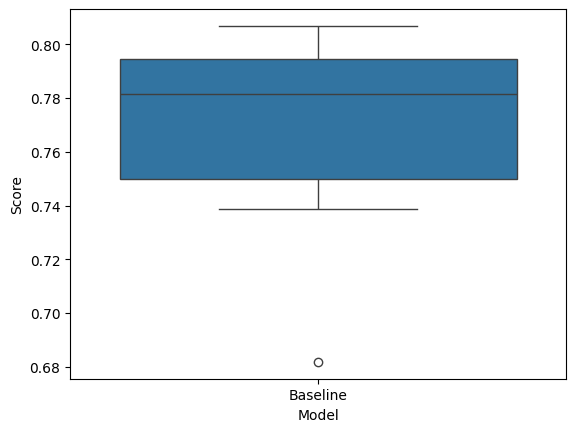

In [11]:
# This time, compare the optimized version of all three models: decision tree, random forest and gradient boosting. You might also want to throw in a logistic regression as a standard of comparison.

# Your code here...

sns.boxplot(pd.DataFrame.from_dict(cross_val_scores), x='Model', y='Score')
plt.show()

In [12]:
# Load Decision Tree metrics
with open('decision_tree_metrics.pkl', 'rb') as file:
    metrics_dt = pickle.load(file)

# Load Random Forest metrics
with open('random_forest_metrics.pkl', 'rb') as file:
    metrics_rf = pickle.load(file)

# Extract metrics
fpr_dt, tpr_dt, roc_auc_dt = metrics_dt['fpr'], metrics_dt['tpr'], metrics_dt['roc_auc']
fpr_rf, tpr_rf, roc_auc_rf = metrics_rf['fpr'], metrics_rf['tpr'], metrics_rf['roc_auc']

In [13]:
# Load Decision Tree precision-recall metrics
with open('decision_tree_precision_recall.pkl', 'rb') as file:
    metrics_dt = pickle.load(file)

precision_dt = metrics_dt['precision']
recall_dt = metrics_dt['recall']

# Load Random Forest precision-recall metrics
with open('random_forest_precision_recall.pkl', 'rb') as file:
    metrics_rf = pickle.load(file)

precision_rf = metrics_rf['precision']
recall_rf = metrics_rf['recall']


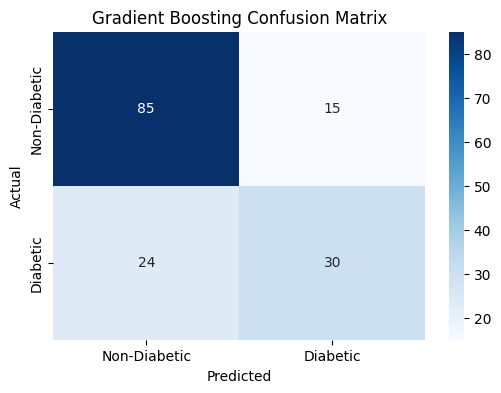

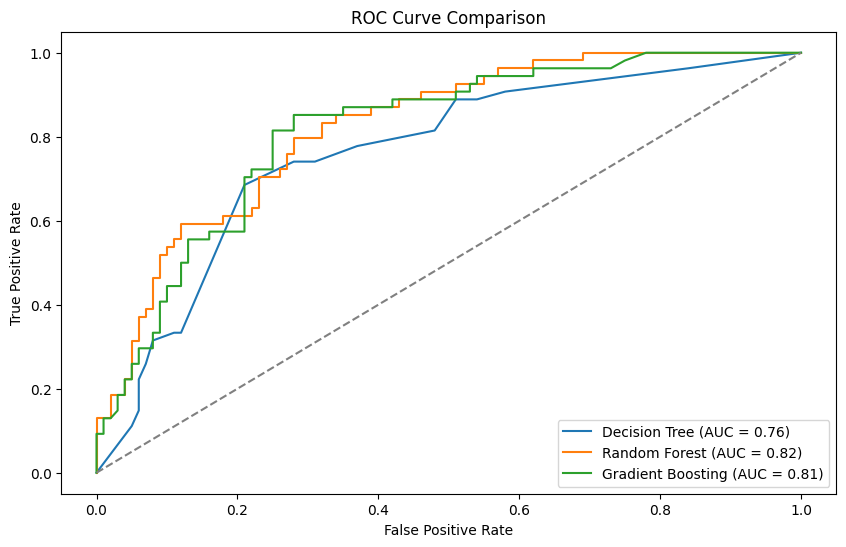

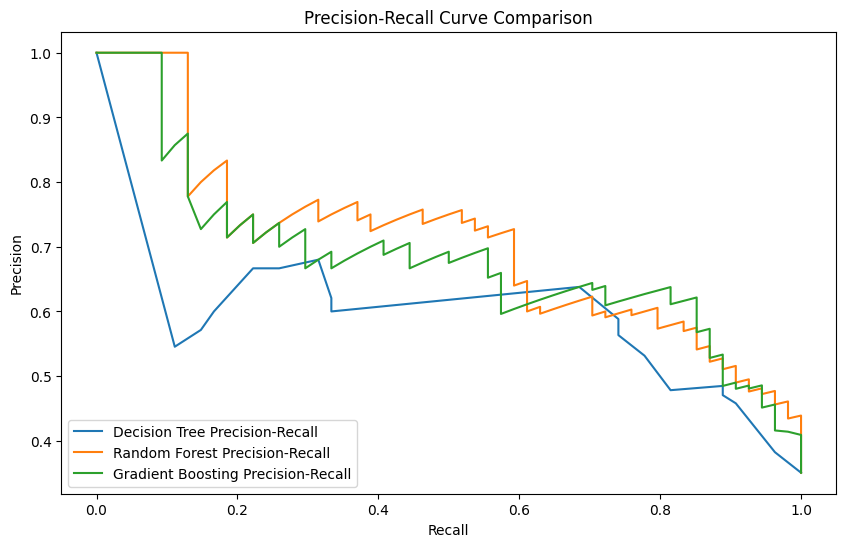

In [14]:
# Evaluate the Gradient Boosting model
y_pred_gb = best_gradBoost.predict(X_test)
y_prob_gb = best_gradBoost.predict_proba(X_test)[:, 1]

# Generate confusion matrix and classification report
cm_gb = confusion_matrix(y_test, y_pred_gb)
report_gb = classification_report(y_test, y_pred_gb)

# ROC curve and AUC
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

# Precision-Recall curve
precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_prob_gb)

# Plot confusion matrix
funcs.plot_confusion_matrix(cm_gb, "Gradient Boosting")

# Compare ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {roc_auc_gb:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

# Compare Precision-Recall curves
plt.figure(figsize=(10, 6))
plt.plot(recall_dt, precision_dt, label="Decision Tree Precision-Recall")
plt.plot(recall_rf, precision_rf, label="Random Forest Precision-Recall")
plt.plot(recall_gb, precision_gb, label="Gradient Boosting Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.show()

### 4.2. Test set performance

In [15]:
# Evaluate the test set performance of all three models
# Your code here...

# Comparing with Decision Tree and Random Forest models
# Load or define models
with open('best_decision_tree.pkl', 'rb') as file:
    best_dt = pickle.load(file)

with open('best_random_forest.pkl', 'rb') as file:
    best_rf = pickle.load(file)

# Pass models to the comparison function
models = {
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gradBoost
}
comparison_df = funcs.tabulate_metrics(models, X_test, y_test)

# Print the comparison
print(comparison_df)


               Model  Accuracy  Precision    Recall  F1-Score   ROC AUC
0      Decision Tree  0.727273   0.666667  0.444444  0.533333  0.653241
1      Random Forest  0.766234   0.695652  0.592593  0.640000  0.822963
2  Gradient Boosting  0.746753   0.666667  0.555556  0.606061  0.814630


## 5. Save

### 5.1. Optimized hyperparameters

In [ ]:
with open(config.GRADIENT_BOOSTING_HYPERPARAMETERS, 'wb') as output_file:
    pickle.dump(hyperparameters.best_params_, output_file)

### 5.2. Model

In [ ]:
with open(config.GRADIENT_BOOSTING_MODEL, 'wb') as output_file:
    pickle.dump(model, output_file)